In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent, SatisficingAgent
from ant.centralised import P4

In [2]:
market_size = 20
simulation_length = 400
num_repeats = 30

pure_strategies = {
    "Proportional": ProportionalAgent,
    "Greedy": GreedyAgent,
    "Egalitarian": EgalitarianAgent,
    # "Petty": PettyAgent,
    "Imitation": ImitationAgent,
    "Satisficing": SatisficingAgent
}

# Create all unique 1-to-1 mixtures (e.g. ('Greedy', 'Egalitarian'))
strategy_pairs = list(itertools.combinations(pure_strategies.keys(), 2))
graph_types = ["complete", "random", "grid", "scale-free", "small-world"]

# Dictionary to store all simulation results across the repeats
all_results = {f"{p1}_vs_{p2}": {gtype: [] for gtype in graph_types} for p1, p2 in strategy_pairs}

In [3]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")
    current_seed = 657849724 + repeat
    
    # 1. Generate the Networks ensuring connectivity where required
    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000  
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "small-world": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    half_size = market_size // 2

    for graph_type, graph in graphs.items():
        for p1, p2 in strategy_pairs:
            ClassA = pure_strategies[p1]
            ClassB = pure_strategies[p2]
            
            # 2. Build 1-to-1 mixed agent array
            mixed_agents = []
            for i in range(0, half_size):
                mixed_agents.append(ClassA(id=i, seed=current_seed + i))
            for i in range(half_size, market_size):
                mixed_agents.append(ClassB(id=i, seed=current_seed + i))
                
            # 3. Create Market 
            _market = Market(
                market_size, graph=graph, agents=mixed_agents, seed=current_seed, agent_type=BaseAgent
            )
            
            # Reattach market and initialize properties properly for mixed agents
            for agent in _market.agents:
                agent.market = _market
                agent.received = np.zeros(market_size, dtype=float)
                agent.received_history = np.zeros((10000, market_size), dtype=float)

            # 4. Centralized calculation & Simulation Setup
            optimal_aloc, utility_vec = P4(_market)
            _market.set_market_equilibrium(optimal_aloc, utility_vec)
            
            simulated_state = _market.simulate(simulation_length)
            all_results[f"{p1}_vs_{p2}"][graph_type].append(simulated_state)

Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


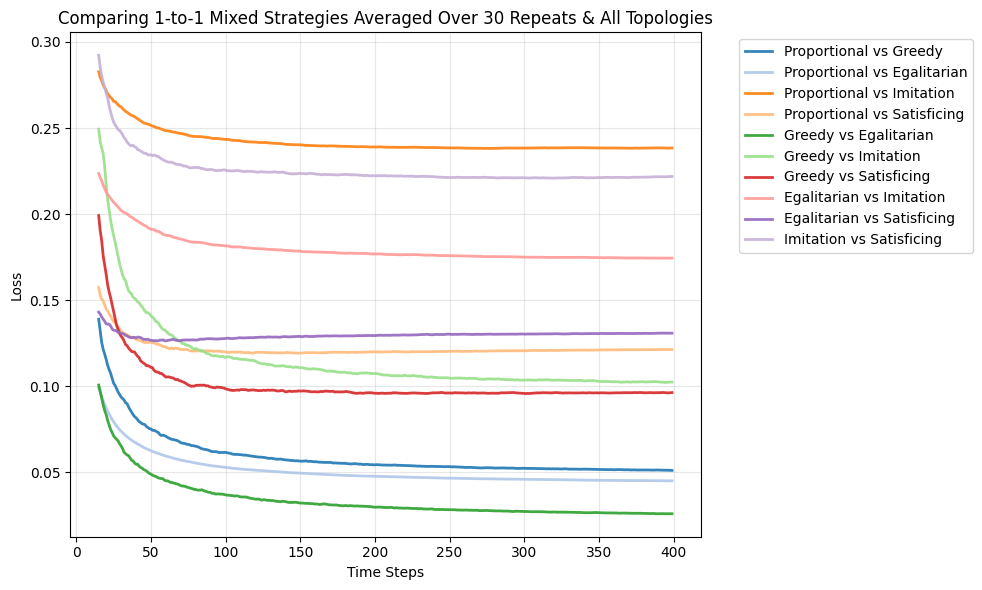

In [5]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

# Generate a list of 20 distinct colors for the 15 total pairs
colors = plt.cm.tab20.colors

plt.figure(figsize=(10, 6))

for idx, pair_name in enumerate(all_results.keys()):
    all_topologies_average = []
    
    for graph_type in graph_types:
        states_array = np.array(all_results[pair_name][graph_type])
        
        # Calculate the average loss per timestep across the repeats
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)

    # Calculate the grand average per timestep over ALL topologies and repeats for THIS pair
    grand_average = np.mean(all_topologies_average, axis=0)
    
    plt.plot(
        time_steps,
        grand_average[training_period:],
        label=f"{pair_name.replace('_', ' ')}",
        color=colors[idx % len(colors)],
        linewidth=2,
        alpha=0.9
    )

plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title(f"Comparing 1-to-1 Mixed Strategies Averaged Over {num_repeats} Repeats & All Topologies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

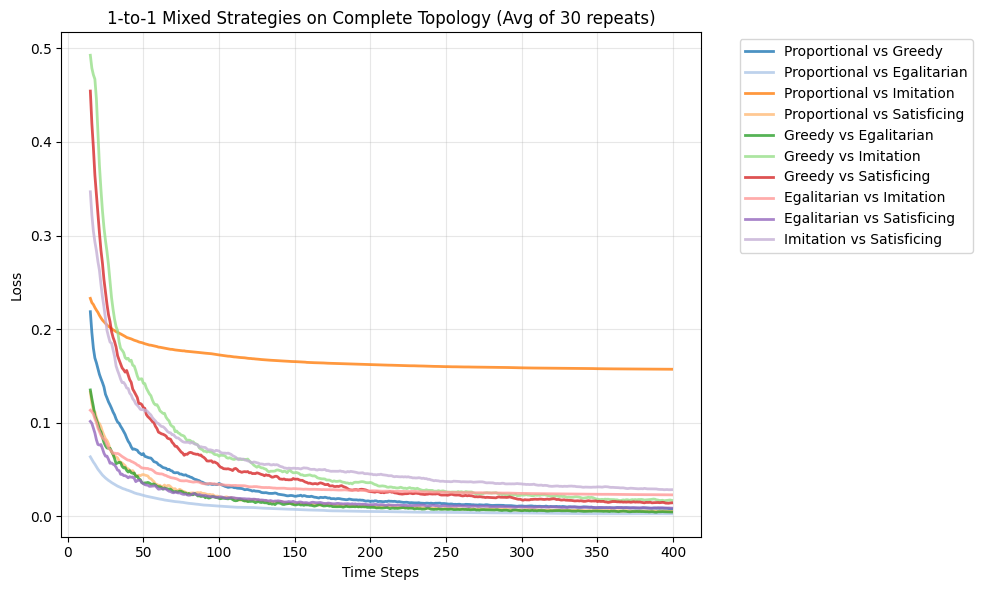

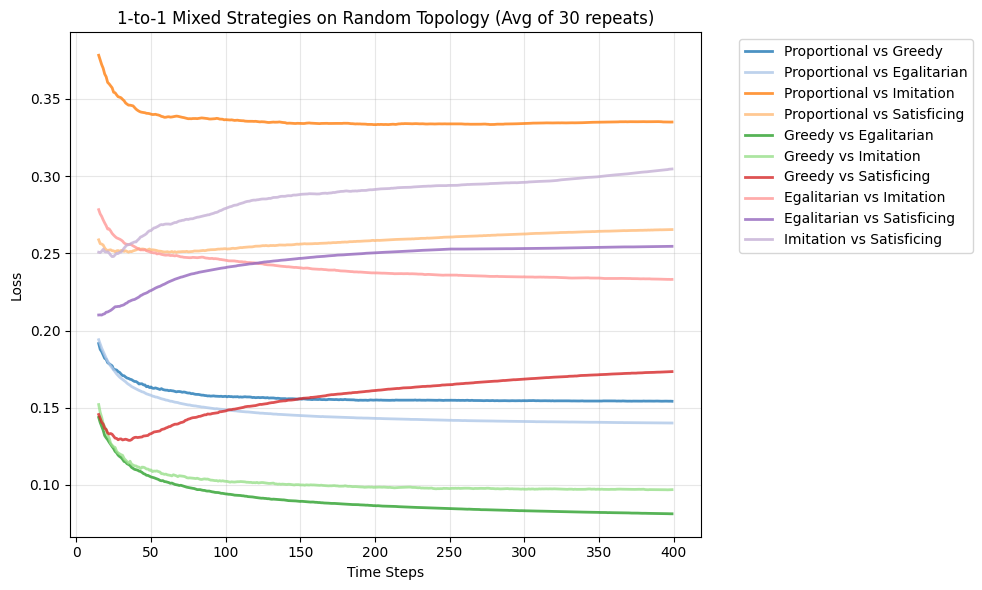

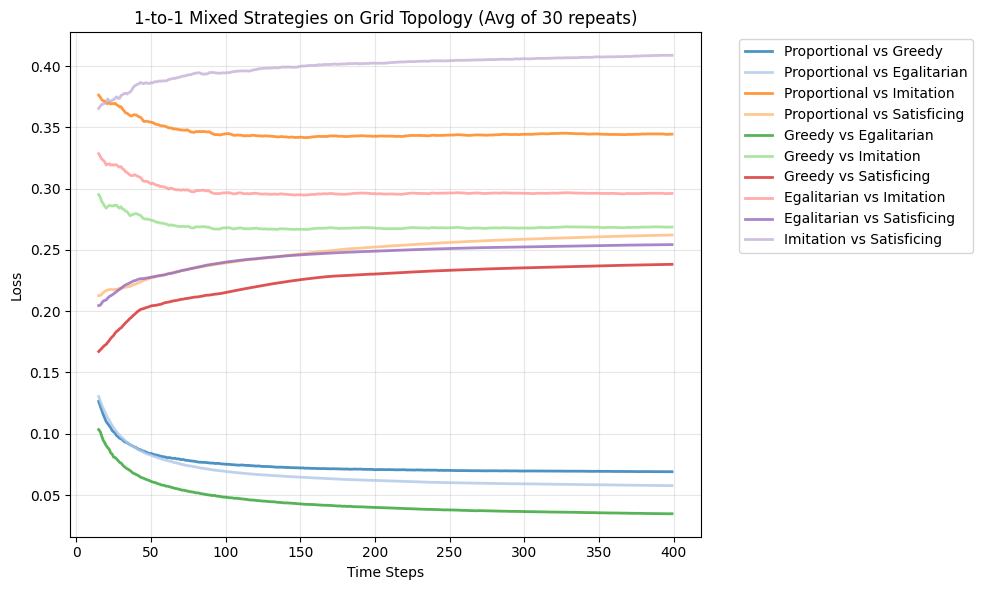

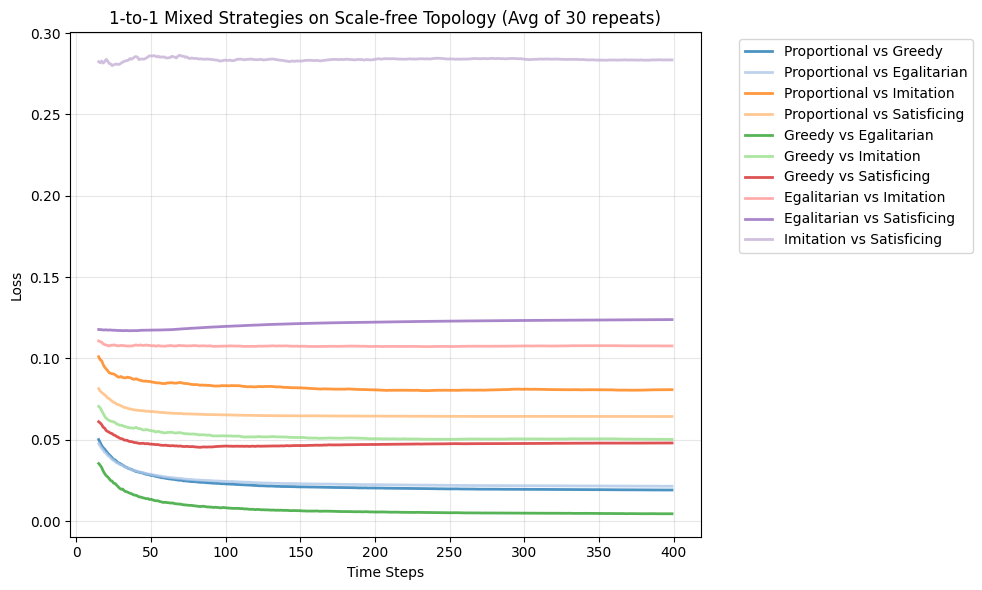

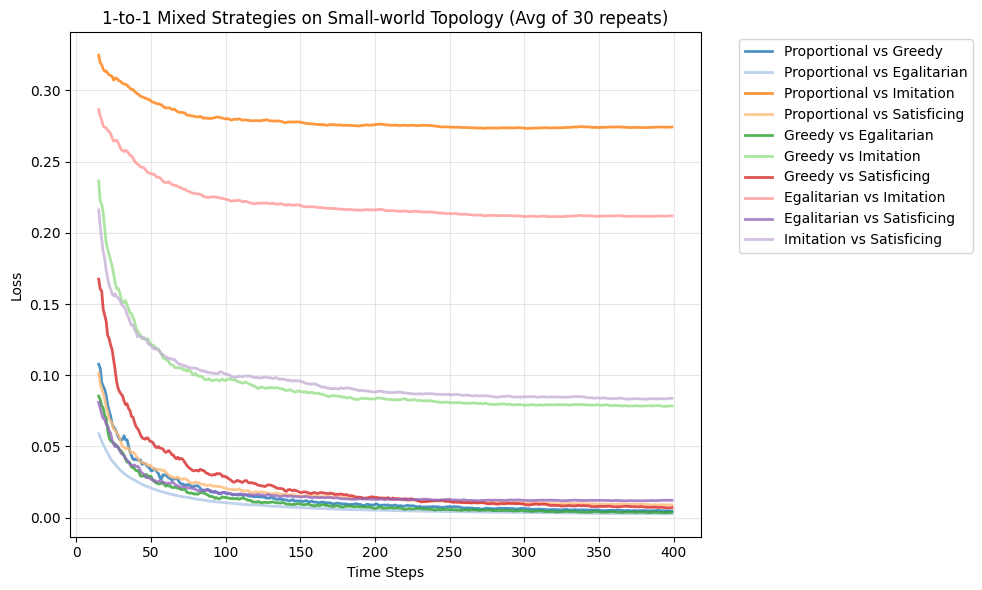

In [4]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

# Generate a list of 20 distinct colors
colors = plt.cm.tab20.colors

for graph_type in graph_types:
    plt.figure(figsize=(10, 6))
    
    for idx, pair_name in enumerate(all_results.keys()):
        states_array = np.array(all_results[pair_name][graph_type])
        
        # Calculate the average loss per timestep across the repeats
        avg_state = np.mean(states_array, axis=0)
        
        plt.plot(
            time_steps,
            avg_state[training_period:],
            label=f"{pair_name.replace('_', ' ')}",
            color=colors[idx % len(colors)], # Manually assign from the 20 distinct colors
            linewidth=2,
            alpha=0.8
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Loss")
    plt.title(f"1-to-1 Mixed Strategies on {graph_type.capitalize()} Topology (Avg of {num_repeats} repeats)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()